# Research Question:
### How do education, employment characteristics, and workplace factors influence income, employment outcomes, and employee satisfaction?

## Sub-questions:

### Education and employment outcomes (Dataset 1)
- How do median gross monthly salaries vary between schools?
- Are there notable differences in overall employment rate and full-time permanent employment rate across different universities, schools, or degree programs?

### Income patterns and demographics (Dataset 2 – MOM Employment Tables)
- How does median gross monthly income vary across different occupations, and are there observable differences between males and females?
- How does median gross monthly income vary across highest qualifications, and how does it change with age?
  
### Employee satisfaction and workplace perception (Dataset 3 – Glassdoor Reviews)
- How do factors like work-life balance, career opportunities, and senior management affect overall employee satisfaction between current vs former employees?
- Are there differences in recommendation likelihood between current vs former employees? 

## Dataset 1 – Education & Employment Outcomes
### This dataset contains information about graduates from various universities, colleges, and degree programs. The key variables include:
- **University, College, Degree**: Educational background of the graduates.
- **Employment Rate Overall**: Percentage of graduates employed in any capacity.
- **Employment Rate Full-Time Permanent**: Percentage of graduates in full-time permanent employment.
- **Gross Monthly Median**: Median starting salary for graduates.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset 1
df_info = pd.read_csv("C:/Users/User/OneDrive - Singapore Polytechnic/Desktop/pdas ca2 dataset/CA2 Datasets/CA2 Datasets/(1) graduate employment survey modified.csv")
df_employ = pd.read_csv("C:/Users/User/OneDrive - Singapore Polytechnic/Desktop/pdas ca2 dataset/CA2 Datasets/CA2 Datasets/(2) graduate employment survey modified .csv")

# Add 'Key' to df_employ for merging
df_employ['Key'] = df_info['Key'] 

# Choose the columns
df_info_small = df_info[['Key', 'year', 'university', 'school', 'degree']]
df_employ_small = df_employ[['Key','employment_rate_overall','employment_rate_ft_perm','gross_monthly_median']]

# Merge on 'key'
df1 = pd.merge(df_info_small, df_employ_small, on='Key', how='inner')

# Preview merged dataset
df1.head()

,Key,year,university,school,degree,employment_rate_overall,employment_rate_ft_perm,gross_monthly_median
0,1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,97.4,96.1,3350
1,2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),97.1,95.7,2700
2,3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),90.9,85.7,3000
3,4,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,87.5,87.5,3400
4,5,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,95.3,95.3,3500


In [2]:
# Check info and missing values
df1.info()
df1.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Key                      5135 non-null   int64 
 1   year                     5135 non-null   object
 2   university               5135 non-null   object
 3   school                   5135 non-null   object
 4   degree                   5135 non-null   object
 5   employment_rate_overall  5027 non-null   object
 6   employment_rate_ft_perm  5027 non-null   object
 7   gross_monthly_median     5027 non-null   object
dtypes: int64(1), object(7)
memory usage: 321.1+ KB


Key                          0
year                         0
university                   0
school                       0
degree                       0
employment_rate_overall    108
employment_rate_ft_perm    108
gross_monthly_median       108
dtype: int64

In [3]:
# Convert employment rates and salary to numeric, coerce errors to NaN
df1['employment_rate_overall'] = pd.to_numeric(df1['employment_rate_overall'].str.strip(), errors='coerce')
df1['employment_rate_ft_perm'] = pd.to_numeric(df1['employment_rate_ft_perm'].str.strip(), errors='coerce')
df1['gross_monthly_median'] = pd.to_numeric(df1['gross_monthly_median'], errors='coerce')

# Convert employment rates to proportions
df1['employment_rate_overall'] = df1['employment_rate_overall'] / 100
df1['employment_rate_ft_perm'] = df1['employment_rate_ft_perm'] / 100

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Key                      5135 non-null   int64  
 1   year                     5135 non-null   object 
 2   university               5135 non-null   object 
 3   school                   5135 non-null   object 
 4   degree                   5135 non-null   object 
 5   employment_rate_overall  4656 non-null   float64
 6   employment_rate_ft_perm  4656 non-null   float64
 7   gross_monthly_median     4656 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 321.1+ KB


In [4]:
# Drop rows with missing values in the key columns for analysis
df1_clean = df1.dropna(subset=['employment_rate_overall','employment_rate_ft_perm','gross_monthly_median'])

df1_clean.isnull().sum()

Key                        0
year                       0
university                 0
school                     0
degree                     0
employment_rate_overall    0
employment_rate_ft_perm    0
gross_monthly_median       0
dtype: int64

### Data Cleaning
- Checked for missing values and ensured key columns are numeric.
- Converted employment rates from percentages to proportions.
- Dropped rows with missing values in employment and salary columns to ensure accurate analysis.

In [5]:
# Numeric summary
df1_clean[['employment_rate_overall','employment_rate_ft_perm','gross_monthly_median']].describe()

,employment_rate_overall,employment_rate_ft_perm,gross_monthly_median
count,4656.000000,4656.000000,4656.000000
mean,0.917617,0.819546,3584.053316
std,0.065241,0.145365,780.663890
min,0.667000,0.143000,250.000000
25%,0.880000,0.742000,3200.000000
50%,0.930000,0.855000,3500.000000
75%,0.970000,0.930000,3900.000000
max,1.000000,1.000000,6600.000000


- Average overall employment rate: ~91.8%
- Average full-time permanent employment rate: ~82%
- Median gross monthly salary: ~$3,584
- Wide variation exists across degrees and schools

In [6]:
# Unique schools
unique_schools = df1_clean['school'].unique()
print(f'Total schools: {len(unique_schools)}')
print(unique_schools)

# Unique degrees
unique_degrees = df1_clean['degree'].unique()
print(f'Total degrees: {len(unique_degrees)}')
print(unique_degrees)

Total schools: 69
['College of Business (Nanyang Business School)' 'College of Engineering'
 'College of Humanities, Arts & Social Sciences' 'College of Sciences'
 'National Institute of Education (NIE)'
 'Faculty of Arts & Social Sciences' 'NUS Business School'
 'School of Computing' 'Faculty of Dentistry'
 'School of Design & Environment' 'Faculty of Engineering'
 'Faculty of Law' 'YLL School of Medicine' 'Faculty of Science'
 'School of Accountancy (4-year programme) *'
 'School of Business (4-year programme) *'
 'School of Economics (4-year programme) *'
 'School of Information Systems (4-year programme) *'
 'School of Social Sciences (4-year programme) *'
 'School of Law (4-year programme) *' 'DigiPen Institute of Technology'
 'The Glasgow School of Art' 'Newcastle University'
 'Technische Universität München' 'The Culinary Institute of America'
 'Trinity College Dublin' 'University of Glasgow'
 'University of Manchester' 'University of Nevada, Las Vegas'
 'Wheelock College' 'Yong

In [7]:
# Simplify degrees into major fields using keyword matching
def simplify_degree(degree):
    degree = str(degree).lower()
    if any(x in degree for x in ['engineering', 'aerospace', 'mechanical', 'civil', 'electrical', 'computer', 'bio', 'chemical', 'materials', 'industrial', 'naval', 'offshore']):
        return 'Engineering'
    elif any(x in degree for x in ['accountancy', 'business', 'economics', 'management', 'finance', 'marketing']):
        return 'Business & Economics'
    elif any(x in degree for x in ['psychology', 'sociology', 'arts', 'communication', 'linguistics', 'public policy']):
        return 'Arts & Social Sciences'
    elif any(x in degree for x in ['medicine', 'nursing', 'dental', 'pharmacy', 'health', 'therap']):
        return 'Medicine & Health'
    elif any(x in degree for x in ['science', 'math', 'biology', 'physics', 'chemistry']):
        return 'Science'
    elif any(x in degree for x in ['law']):
        return 'Law'
    else:
        return 'Other'

df1_clean['degree_field'] = df1_clean['degree'].apply(simplify_degree)
#---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Simplify schools using keyword matching
def simplify_school(school):
    school = str(school).lower()
    if 'engineering' in school:
        return 'Engineering'
    elif 'business' in school:
        return 'Business'
    elif 'arts' in school or 'humanities' in school or 'social sciences' in school:
        return 'Arts & Social Sciences'
    elif 'science' in school:
        return 'Science'
    elif 'medicine' in school or 'dental' in school or 'law' in school:
        return 'Professional / Law / Medicine'
    elif 'computing' in school or 'information systems' in school:
        return 'Computing / IT'
    elif 'sit' in school or 'trinity' in school or 'overseas' in school:
        return 'SIT / Overseas'
    else:
        return 'Other'

df1_clean['school_simplified'] = df1_clean['school'].apply(simplify_school)

# Check results
df1_clean[['degree', 'degree_field', 'school', 'school_simplified']].head(10)

C:\Users\User\AppData\Local\Temp\ipykernel_50188\1196262142.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_clean['degree_field'] = df1_clean['degree'].apply(simplify_degree)
C:\Users\User\AppData\Local\Temp\ipykernel_50188\1196262142.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_clean['school_simplified'] = df1_clean['school'].apply(simplify_school)


,degree,degree_field,school,school_simplified
0,Accountancy and Business,Business & Economics,College of Business (Nanyang Business School),Business
1,Accountancy (3-yr direct Honours Programme),Business & Economics,College of Business (Nanyang Business School),Business
2,Business (3-yr direct Honours Programme),Business & Economics,College of Business (Nanyang Business School),Business
3,Business and Computing,Business & Economics,College of Business (Nanyang Business School),Business
4,Aerospace Engineering,Engineering,College of Engineering,Engineering
5,Bioengineering,Engineering,College of Engineering,Engineering
6,Chemical and Biomolecular Engineering,Engineering,College of Engineering,Engineering
7,Computer Engineering,Engineering,College of Engineering,Engineering
8,Civil Engineering,Engineering,College of Engineering,Engineering
9,Computer Science,Engineering,College of Engineering,Engineering


In [8]:
# Check unique values and counts for simplified columns
print("Unique degree fields:", df1_clean['degree_field'].nunique())
print(df1_clean['degree_field'].unique())

print("/nUnique schools simplified:", df1_clean['school_simplified'].nunique())
print(df1_clean['school_simplified'].unique())

Unique degree fields: 7
['Business & Economics' 'Engineering' 'Other' 'Arts & Social Sciences'
 'Science' 'Medicine & Health' 'Law']
/nUnique schools simplified: 8
['Business' 'Engineering' 'Arts & Social Sciences' 'Science' 'Other'
 'Computing / IT' 'Professional / Law / Medicine' 'SIT / Overseas']


## Simplifying Schools and Degrees

The original dataset contains a large number of unique schools (69) and degree programs (302), which would make visualization and analysis very complex and difficult to interpret. To make the data more manageable and meaningful, we grouped the degrees and schools into broader categories using keyword-based rules.

### Degree Fields
Degrees were simplified into 7 major fields based on keywords found in the degree names:

- **Business & Economics** – includes Accountancy, Business, Economics, Finance, Marketing, and Management programs  
- **Engineering** – includes all engineering-related degrees such as Mechanical, Civil, Electrical, Aerospace, Computer, Bioengineering, Chemical, Materials, Industrial, Naval, and Offshore Engineering  
- **Arts & Social Sciences** – includes Arts, Communication, Linguistics, Psychology, Sociology, and Public Policy programs  
- **Science** – includes general Science, Mathematics, Physics, Chemistry, and Biology-related degrees  
- **Medicine & Health** – includes Medicine, Nursing, Dental, Pharmacy, and Health-related degrees  
- **Law** – all law programs  
- **Other** – degrees that do not fit into the above categories  

### Schools
Similarly, schools were simplified into 8 categories:

- **Business** – all business-related schools  
- **Engineering** – all engineering schools  
- **Arts & Social Sciences** – schools related to Arts, Humanities, or Social Sciences  
- **Science** – general science schools  
- **Computing / IT** – schools focused on computing or information systems  
- **Professional / Law / Medicine** – includes Medicine, Dental, and Law faculties  
- **SIT / Overseas** – Singapore Institute of Technology or overseas partner institutions  
- **Other** – schools that do not fall into the above categories  

By reducing the number of categories, we can create clearer visualizations and identify patterns more effectively.

## Boxplot of Median Gross Monthly Salary by School

To explore the distribution of median gross monthly salaries across different schools, a boxplot is created.  
This visualization helps to identify:  

- The central tendency and spread of salaries for each school  
- Potential outliers in the data  

The `school_simplified` column is used to group salaries into major school categories for clarity.

C:\Users\User\AppData\Local\Temp\ipykernel_50188\3284299766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='school_simplified', y='gross_monthly_median', data=df1_clean, palette='Set1')


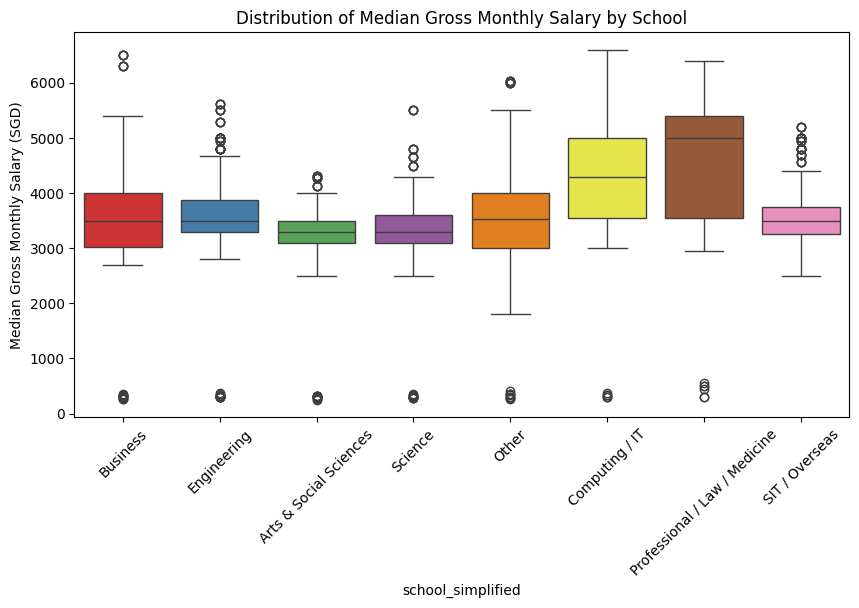

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(x='school_simplified', y='gross_monthly_median', data=df1_clean, palette='Set1')
plt.ylabel('Median Gross Monthly Salary (SGD)')
plt.title('Distribution of Median Gross Monthly Salary by School')
plt.xticks(rotation=45)
plt.show()

## Handling Outliers in Median Gross Monthly Salary

Outliers in the `gross_monthly_median` column can distort visualizations and summary statistics. To handle these outliers, the Interquartile Range (IQR) method is applied:

1. **Calculate the IQR**:  
   IQR = Q3 (75th percentile) − Q1 (25th percentile)

2. **Define the bounds**:  
   - Lower bound = Q1 − 1.5 × IQR  
   - Upper bound = Q3 + 1.5 × IQR

3. **Filter the data**:  
   Only retain rows where the median gross monthly salary falls within the calculated bounds.

This process ensures that extreme salary values do not skew the analysis, while maintaining the overall structure of the dataset.

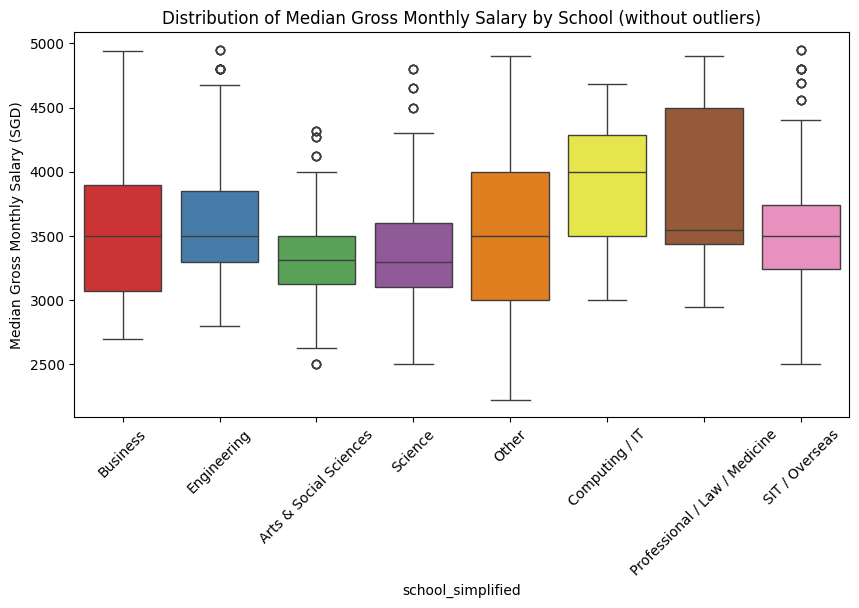

In [52]:
# Calculate Q1 and Q3 for 'gross_monthly_median' to identify the interquartile range (IQR)
Q1 = df1_clean['gross_monthly_median'].quantile(0.25)
Q3 = df1_clean['gross_monthly_median'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds to detect outliers (1.5 * IQR rule)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataset to remove outliers based on the calculated bounds
df_no_outliers = df1_clean[
    (df1_clean['gross_monthly_median'] >= lower_bound) &
    (df1_clean['gross_monthly_median'] <= upper_bound)
]

plt.figure(figsize=(10,5))
sns.boxplot(x='school_simplified', y='gross_monthly_median', hue='school_simplified', data=df_no_outliers, palette='Set1')
plt.ylabel('Median Gross Monthly Salary (SGD)')
plt.title('Distribution of Median Gross Monthly Salary by School (without outliers)')
plt.xticks(rotation=45)
plt.show()

## Interpretation: Distribution of Median Gross Monthly Salary by School

The boxplot shows the distribution of median gross monthly salaries across simplified school categories after removing outliers using the IQR method. Key observations include:

1. **Higher-paying schools**: 
   - Graduates from **Professional / Law / Medicine** and **Computing / IT** schools have the highest median salaries.
   - Professional / Law / Medicine shows the widest range and highest upper quartile, indicating high earning potential but some variability.

2. **Moderate-paying schools**: 
   - **Business**, **Engineering**, **Science**, and **Other** schools have similar median salaries, around SGD 3,000–4,000.
   - Narrower interquartile ranges suggest more consistent salary outcomes among graduates.

3. **Lower-paying schools**: 
   - **Arts & Social Sciences** graduates have the lowest median salaries.
   - Tight IQR indicates less variability but generally lower starting salaries compared to other categories.

4. **Outliers**: 
   - Even after filtering, some outliers remain in all categories, representing exceptionally high or low salaries.

**Conclusion:** The school attended appears to significantly influence starting salary, with graduates from Professional / Law / Medicine and Computing / IT schools generally achieving higher median incomes.

## Bar Chart of Average Employment Rates by Degree Field

This bar chart shows the mean overall employment rate and full-time permanent employment rate for each major degree field.  

- The data is grouped by `degree_field` to simplify the large number of individual degrees.  
- Sorting by `employment_rate_overall` allows easier comparison across fields.  
- Both overall employment rate and full-time permanent employment rate are displayed side by side for each degree field.

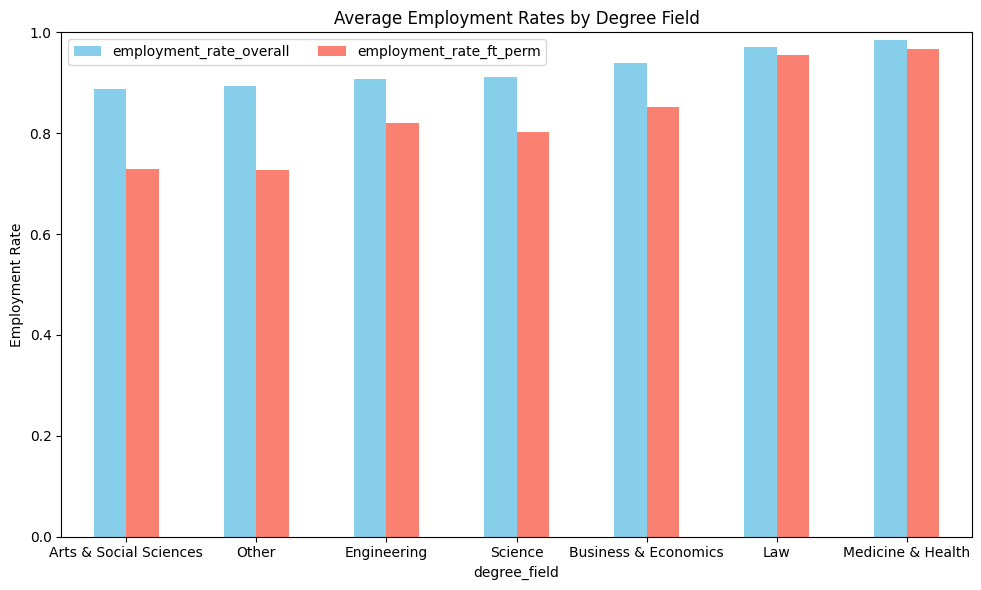

In [11]:
# Group the data by 'degree_field' and calculate the average employment rates
degree_emp = df1_clean.groupby('degree_field')[['employment_rate_overall', 'employment_rate_ft_perm']].mean().reset_index()

# Sort the dataframe by overall employment rate for better visualization
degree_emp = degree_emp.sort_values(by='employment_rate_overall', ascending=True)

degree_emp.plot(x='degree_field', kind='bar', stacked=False, color=['skyblue','salmon'], figsize=(10,6))
plt.ylabel('Employment Rate')
plt.title('Average Employment Rates by Degree Field')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='upper center',bbox_to_anchor=(0.27, 1.00), ncol=2)
plt.tight_layout()
plt.show()

## Interpretation of Average Employment Rates by Degree Field

The bar chart illustrates the mean overall employment rate (`employment_rate_overall`) and full-time permanent employment rate (`employment_rate_ft_perm`) across seven major degree fields. Key observations are as follows:

1. **Highest Employment Rates**
   - Graduates in **Medicine & Health** and **Law** have the highest employment rates, with both overall and full-time permanent rates close to 100%.
   - This suggests strong employability in these fields, likely due to high demand and specialized skill sets.

2. **Moderate Employment Rates**
   - **Business & Economics** and **Engineering** graduates also show high overall employment rates (above 0.9), but the full-time permanent rate is slightly lower, indicating a proportion may be employed in temporary or part-time positions.

3. **Lower Employment Rates**
   - Graduates in **Arts & Social Sciences** and the **Other** category have the lowest employment outcomes, with full-time permanent employment rates around 0.72–0.73.
   - This highlights potential challenges in securing stable, full-time employment for these fields.

4. **Gap Between Overall and Full-Time Permanent Employment**
   - The difference between overall employment and full-time permanent employment is more pronounced in **Arts & Social Sciences**, **Science**, and **Engineering**, suggesting that while many graduates find work, not all secure permanent positions.
   - Conversely, in **Medicine & Health** and **Law**, the gap is minimal, indicating stable and permanent employment is the norm.

**Conclusion:**  
Degree field is strongly associated with both overall employability and full-time permanent employment. Fields such as **Medicine & Health** and **Law** provide the most secure employment outcomes, while **Arts & Social Sciences** and miscellaneous degrees may require additional career support or flexible job strategies.

## Dataset 2: MOM Labour Force Report 2023 (Section C – Income)
Dataset 2 is obtained from the **Ministry of Manpower (MOM) Labour Force Report 2023**, Section C, which reports the **median gross monthly income** of full-time employed residents aged 15 years and over (excluding full-time national servicemen).

This dataset provides income breakdowns across multiple demographic and employment categories, including:

- Occupation

- Industry

- Sex

- Age group

- Highest qualification attained

The focus of this analysis is based on:

- **Table C2 (Occupation and Sex)**

- **Table C6 (Age Group and Qualification)**

The key target variable is:

**Median Gross Monthly Income (SGD, excluding employer CPF contributions)**

Median income represents the midpoint of the income distribution, where half of workers earn above and half earn below this value.

## Table C2: Median Income by Occupation and Sex

Table C2 reports the median gross monthly income by occupation and gender.
The analysis focuses on the income values excluding employer CPF, as these better reflect direct take-home wage comparisons.

In [12]:
# Read Section C2 from Excel, skipping header rows
df_c2 = pd.read_excel(
    "C:/Users/User/OneDrive - Singapore Polytechnic/Desktop/pdas ca2 dataset/LFR2023_SectionC.xlsx",
    sheet_name="C2",
    skiprows=7
)

# rename columns
df_c2.columns = [
    "Occupation",
    "Incl_CPF_Total",
    "Incl_CPF_Male",
    "Incl_CPF_Female",
    "Excl_CPF_Total",
    "Excl_CPF_Male",
    "Excl_CPF_Female"
]

# select columns
df_c2_selected = df_c2[
    ["Occupation", "Excl_CPF_Total", "Excl_CPF_Male", "Excl_CPF_Female"]
]

# Preview dataset
df_c2_selected.head()

,Occupation,Excl_CPF_Total,Excl_CPF_Male,Excl_CPF_Female
0,Total,4550.0,4875.0,4333.0
1,PMETs,6000.0,6500.0,5700.0
2,Managers & Administrators (Including Working P...,9967.0,10292.0,9000.0
3,Professionals,7000.0,7500.0,6500.0
4,Associate Professionals & Technicians,4000.0,4000.0,4000.0


In [29]:
df_c2_selected.info()
df_c2_selected.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 1 to 10
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Occupation       10 non-null     object 
 1   Excl_CPF_Total   10 non-null     float64
 2   Excl_CPF_Male    10 non-null     float64
 3   Excl_CPF_Female  10 non-null     float64
dtypes: float64(3), object(1)
memory usage: 400.0+ bytes


Occupation         0
Excl_CPF_Total     0
Excl_CPF_Male      0
Excl_CPF_Female    0
dtype: int64

In [33]:
# drop rows with NaN
df_c2_selected = df_c2_selected.dropna(subset=["Occupation"])

# drop the rows with empty string
df_c2_selected = df_c2_selected[df_c2_selected["Occupation"].str.strip() != ""]

# delete the rows that include “1)” or “Source” or “Note”
df_c2_selected = df_c2_selected[
    ~df_c2_selected["Occupation"].str.contains("Source|Note|Total|1\\)", na=False)
]

df_c2_long = df_c2_selected.melt(
    id_vars="Occupation",
    value_vars=["Excl_CPF_Total", "Excl_CPF_Male", "Excl_CPF_Female"],
    var_name="Sex",
    value_name="Median_Gross_Monthly_Income"
)

# Rename the columns
df_c2_long["Sex"] = df_c2_long["Sex"].replace({
    "Excl_CPF_Total": "Total",
    "Excl_CPF_Male": "Male",
    "Excl_CPF_Female": "Female"
})

# drop the Total sex row
df_c2_long = df_c2_long[df_c2_long["Sex"].isin(["Male", "Female"])]

df_c2_long = df_c2_long.reset_index(drop=True)

df_c2_long.head()

,Occupation,Sex,Median_Gross_Monthly_Income
0,PMETs,Male,6500.0
1,Managers & Administrators (Including Working P...,Male,10292.0
2,Professionals,Male,7500.0
3,Associate Professionals & Technicians,Male,4000.0
4,Non-PMETs,Male,2492.0


## Data Cleaning and Filtering

The raw MOM Excel table includes additional rows such as:

- Overall totals

- Footnotes (e.g., “1)”)

- Notes and source references

These rows are not part of occupation-level analysis and may distort comparisons.
Therefore, they were removed to ensure only valid occupation categories remain.

After cleaning, **10 occupation groups** were retained for further analysis.

## Reshaping Data for Gender Comparison

The dataset originally stores male and female income in separate columns (wide format).

To enable easier comparison and visualisation, the table was transformed into **long format
using `melt()`**, producing three key columns:

- Occupation
- Sex
- Median Gross Monthly Income

This structure is more suitable for plotting grouped trends between males and females.

In [35]:
df_c2_long.info()
df_c2_long.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Occupation                   20 non-null     object 
 1   Sex                          20 non-null     object 
 2   Median_Gross_Monthly_Income  20 non-null     float64
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes


Occupation                     0
Sex                            0
Median_Gross_Monthly_Income    0
dtype: int64

## Visualisation: Median Income by Occupation and Sex (Table C2)

A line chart is used to visualise the income gradient across occupations while allowing direct comparison between male and female median incomes.

The chart highlights both:

- **Income stratification across occupation skill levels**

- **Gender-based income differences within occupations**

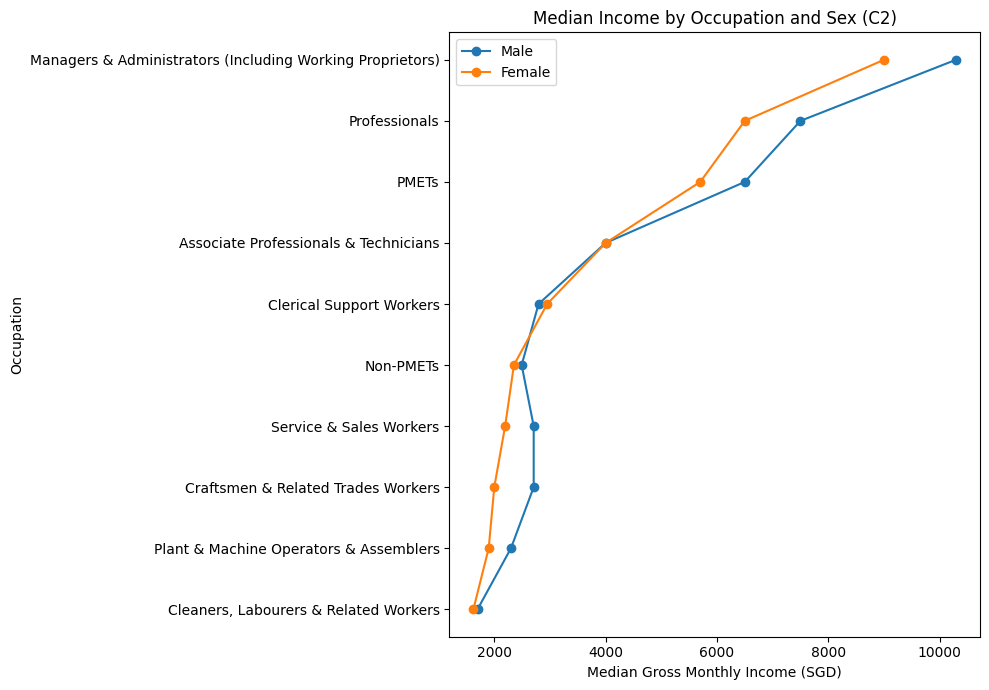

In [14]:
c2_pivot = df_c2_long.pivot_table( index="Occupation", columns="Sex", values="Median_Gross_Monthly_Income" ).sort_values("Female") 
plt.figure(figsize=(10,7))
plt.plot(c2_pivot["Male"], c2_pivot.index, marker="o", label="Male")
plt.plot(c2_pivot["Female"], c2_pivot.index, marker="o", label="Female")

plt.title("Median Income by Occupation and Sex (C2)")
plt.ylabel("Occupation")
plt.xlabel("Median Gross Monthly Income (SGD)")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation of the Line Chart (C2)
### 1. Income Variation Across Occupations

The line chart demonstrates a clear and strong gradient in median gross monthly income across different occupations. 
- The **lowest median incomes** are observed in **Cleaners, Labourers & Related Workers**.
- The **highest median incomes** are seen in **Managers & Administrators**.

This pattern suggests a strong association between job skill level and earnings: 
- Occupations that require higher responsibility, expertise, or managerial roles generally command higher median incomes.
- The income progression from lower-skilled to higher-skilled occupations is consistent and indicates structural wage stratification based on occupation type.

### 2. Gender Differences within Occupations

The chart also highlights the gender income gap across occupations:

- **Lower-income occupations and high-income occupations** show that **females typically earn less than males**.

- **Mid-income occupations** exhibit smaller gender gaps, and in some cases, **female median income is similar to or slightly higher than male**.

This indicates that gender wage differences are not uniform across all occupations; the gap varies depending on occupation type and wage level.

In [39]:
# =====================================================
# Additional Analysis: Gender Pay Gap by Occupation
# =====================================================

# Calculate income gap (Male - Female) for each occupation
c2_pivot["Gender_Gap"] = c2_pivot["Male"] - c2_pivot["Female"]

# Sort occupations by largest gender gap
c2_gap_sorted = c2_pivot.sort_values("Gender_Gap", ascending=False)

# Display the results
c2_gap_sorted

Sex,Female,Male,Gender_Gap
Occupation,,,
Managers & Administrators (Including Working Proprietors),9000.0,10292.0,1292.0
Professionals,6500.0,7500.0,1000.0
PMETs,5700.0,6500.0,800.0
Craftsmen & Related Trades Workers,2000.0,2708.0,708.0
Service & Sales Workers,2195.0,2708.0,513.0
Plant & Machine Operators & Assemblers,1900.0,2300.0,400.0
Non-PMETs,2353.0,2492.0,139.0
"Cleaners, Labourers & Related Workers",1625.0,1700.0,75.0
Associate Professionals & Technicians,4000.0,4000.0,0.0


In [40]:
print("Average Gender Income Gap (Male - Female):",
      c2_pivot["Gender_Gap"].mean())

Average Gender Income Gap (Male - Female): 477.2


### Additional Gender Gap Analysis

The median income difference between males and females was computed for each occupation:

#### Largest gaps occur in high-paying occupations:

- Managers & Administrators: SGD 1,292

- Professionals: SGD 1,000

- PMETs overall: SGD 800

#### Minimal or no gaps in mid- or low-paying occupations:

- Associate Professionals & Technicians: SGD 0

- Cleaners, Labourers & Related Workers: SGD 75

#### Reverse gap example: 
- Clerical Support Workers, females earn SGD 155 more than males.

#### Average gender income gap across all occupations: 
- SGD 477.2 (Male − Female)

This additional analysis highlights how gender wage differences vary by occupation and are most pronounced in higher-skilled roles.

## Table C6 – Median Income by Age Group and Qualification

Table C6 reports the median gross monthly income of full-time employed residents by age group and highest qualification attained.

The dataset was cleaned and reshaped into long format to enable comparison across age groups and qualifications.

In [15]:
# Read Section C6 from Excel, skipping header rows
df_c6 = pd.read_excel(
    "C:/Users/User/OneDrive - Singapore Polytechnic/Desktop/pdas ca2 dataset/LFR2023_SectionC.xlsx",
    sheet_name="C6",
    skiprows=6
)

# Rename columns for clarity and consistency
df_c6.columns = [
    "Total_Type",
    "Age",
    "Total",
    "Below Secondary",
    "Secondary",
    "Post-Secondary (Non-Tertiary)",
    "Diploma & Professional Qualification",
    "Degree"
]

# Remove unnecessary classification column
df_c6 = df_c6.drop(columns=["Total_Type"])

# Remove aggregated 'Total' age group to keep only actual age bands
df_c6 = df_c6[df_c6["Age"] != "Total"]

# Drop overall total column to focus on education breakdown
df_c6 = df_c6.drop(columns=["Total"])

# Convert education-level columns to numeric values
for col in df_c6.columns[1:]:
    df_c6[col] = pd.to_numeric(df_c6[col], errors="coerce")

df_c6.head()

,Age,Below Secondary,Secondary,Post-Secondary (Non-Tertiary),Diploma & Professional Qualification,Degree
1,15 - 19,NaN,995.0,1989.0,NaN,NaN
2,20 - 24,NaN,2340.0,2340.0,3000.0,4437.0
3,25 - 29,2920.0,3027.0,3042.0,3656.0,5697.0
4,30 - 34,2788.0,3324.0,3510.0,4437.0,7020.0
5,35 - 39,2788.0,3510.0,3744.0,5000.0,8775.0


In [36]:
df_c6.info()
df_c6.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 1 to 52
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   45 non-null     object 
 1   Below Secondary                       36 non-null     float64
 2   Secondary                             44 non-null     float64
 3   Post-Secondary (Non-Tertiary)         44 non-null     float64
 4   Diploma & Professional Qualification  42 non-null     float64
 5   Degree                                42 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.7+ KB


Age                                      5
Below Secondary                         14
Secondary                                6
Post-Secondary (Non-Tertiary)            6
Diploma & Professional Qualification     8
Degree                                   8
dtype: int64

In [37]:
# melt
df_c6_long = df_c6.melt(
    id_vars="Age",
    value_vars=[
        "Below Secondary",
        "Secondary",
        "Post-Secondary (Non-Tertiary)",
        "Diploma & Professional Qualification",
        "Degree"
    ],
    var_name="Qualification",
    value_name="Median_Gross_Monthly_Income"
)

df_c6_long = df_c6_long[df_c6_long["Age"].str.contains(" - ", na=False)]

df_c6_long = df_c6_long[
    df_c6_long["Age"].apply(
        lambda x: int(x.split(" - ")[1]) - int(x.split(" - ")[0]) == 4
    )
]

# drop duplicates
df_c6_long = df_c6_long.drop_duplicates(subset=["Age", "Qualification"], keep="first")

df_c6_long.head(10)

,Age,Qualification,Median_Gross_Monthly_Income
0,15 - 19,Below Secondary,NaN
1,20 - 24,Below Secondary,NaN
2,25 - 29,Below Secondary,2920.0
3,30 - 34,Below Secondary,2788.0
4,35 - 39,Below Secondary,2788.0
5,40 - 44,Below Secondary,3000.0
6,45 - 49,Below Secondary,3000.0
7,50 - 54,Below Secondary,2725.0
8,55 - 59,Below Secondary,2481.0
50,15 - 19,Secondary,995.0


## Data Cleaning and Reshaping

- Removed overall total rows and unnecessary classification columns to keep only actual age bands.

- Converted all education-level columns to numeric.

- Reshaped the dataset from wide to **long format using melt()** to create columns: **Age, Qualification, Median_Gross_Monthly_Income**

After cleaning, 45 observations remain across all age groups and qualifications. Some values were missing (NaN) due to incomplete source data and were ignored in the plots.

In [38]:
df_c6_long.info()
df_c6_long.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 0 to 208
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          45 non-null     object 
 1   Qualification                45 non-null     object 
 2   Median_Gross_Monthly_Income  41 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.4+ KB


Age                            0
Qualification                  0
Median_Gross_Monthly_Income    4
dtype: int64

## Visualisation: Median Income by Age Group and Qualification

A multi-line plot was used to show how income varies across age groups for each qualification level:

- **Each line represents a Qualification.**

- **X-axis shows Age Group, Y-axis shows Median Gross Monthly Income.**

This allows easy comparison of income growth, peak, and decline patterns across qualifications.

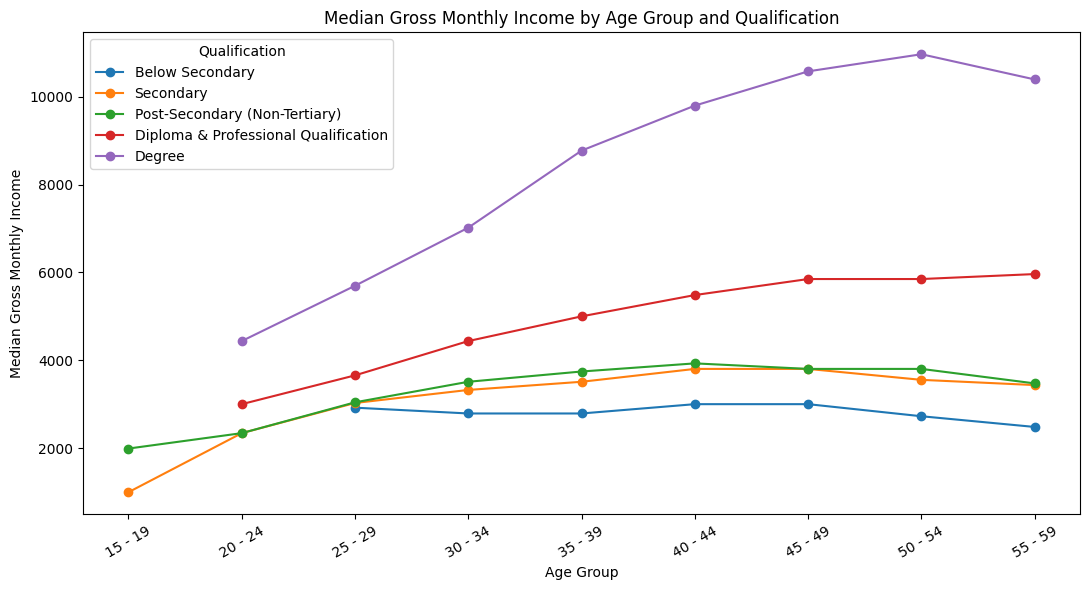

In [22]:
plt.figure(figsize=(11, 6))

for qual in df_c6_long["Qualification"].unique():
    subset = df_c6_long[df_c6_long["Qualification"] == qual]
    plt.plot(
        subset["Age"],
        subset["Median_Gross_Monthly_Income"],
        marker="o",
        label=qual
    )

plt.xlabel("Age Group")
plt.ylabel("Median Gross Monthly Income")
plt.title("Median Gross Monthly Income by Age Group and Qualification")
plt.xticks(rotation=30)
plt.legend(title="Qualification")
plt.tight_layout()
plt.show()

## Interpretation (Table C6: Income by Age Group & Qualification)

### Overall trend
Median gross monthly income generally **increases with age across all qualification levels**, but the rate of growth and peak age differ by qualification.

### Income ranking by qualification
Across all age groups, income consistently follows:

Below Secondary < Secondary < Post-Secondary < Diploma/Professional < Degree

- **Degree holders** start with higher income earlier, grow fastest, and peak around 50–54 (~ 11,000) before slightly declining.
- **Diploma holders** show steady growth but stable around 45–54 (~$5,800–$6,000) and continue to grow after that.
- **Post-secondary, secondary, and below secondary** show **slower growth and peak earlier**, with incomes declining after 40–49.

### Limitations
Median income does not reflect variation within age-qualification groups, part-time employment, seniority, or industry differences.

#### Summary
Higher qualifications lead to higher starting income, faster growth, higher peak income, and longer sustained earnings.
Lower qualifications show limited growth and earlier decline, suggesting fewer career advancement opportunities.

In [43]:
# =====================================================
# Additional Quantitative Insight: Qualification Gap by Age
# =====================================================

# Pivot long dataframe to Age x Qualification table for easier comparison
c6_pivot = df_c6_long.pivot_table(
    index="Age",
    columns="Qualification",
    values="Median_Gross_Monthly_Income"
)

# Calculate income gap: Degree - Secondary at each age group
c6_pivot["Degree_vs_Secondary"] = c6_pivot["Degree"] - c6_pivot["Secondary"]

# Find age group with largest Degree vs Secondary gap
max_gap_age = c6_pivot["Degree_vs_Secondary"].idxmax()
max_gap_value = c6_pivot["Degree_vs_Secondary"].max()

# Optional: show peak income for each qualification
peak_income = c6_pivot.max().drop("Degree_vs_Secondary")

c6_pivot, max_gap_age, max_gap_value, peak_income

(Qualification  Below Secondary   Degree  Diploma & Professional Qualification  \
 Age                                                                             
 15 - 19                    NaN      NaN                                   NaN   
 20 - 24                    NaN   4437.0                                3000.0   
 25 - 29                 2920.0   5697.0                                3656.0   
 30 - 34                 2788.0   7020.0                                4437.0   
 35 - 39                 2788.0   8775.0                                5000.0   
 40 - 44                 3000.0   9800.0                                5485.0   
 45 - 49                 3000.0  10580.0                                5850.0   
 50 - 54                 2725.0  10970.0                                5850.0   
 55 - 59                 2481.0  10396.0                                5963.0   
 
 Qualification  Post-Secondary (Non-Tertiary)  Secondary  Degree_vs_Secondary  
 Age            

### Additional Qualification Gap Analysis

- The income gap between Degree and Secondary holders widens with age.

- The **largest gap** occurs at **age group 50–54**, where **Degree holders earn ~SGD 7,416 more than Secondary holders**.

Peak median incomes by qualification:

- Degree: ~SGD 10,970  
- Diploma & Professional Qualification: ~SGD 5,963  
- Post-Secondary (Non-Tertiary): ~SGD 3,929  
- Secondary: ~SGD 3,803  
- Below Secondary: ~SGD 3,000


This shows that 
- **higher qualifications** not only **start with higher income** but also grow faster and **sustain higher earnings longer**.
- **lower qualifications** show **slower growth and earlier decline**, indicating fewer career advancement opportunities.

## Dataset 3: Glassdoor Employee Reviews – Introduction

### Dataset Overview

This dataset consists of employee reviews collected from Glassdoor, capturing individuals’ perceptions of their workplace experiences across different companies, job roles, and locations. Each review provides quantitative ratings on key workplace factors, as well as indicators of employee sentiment such as overall satisfaction and willingness to recommend the company.

This dataset is used to examine how **workplace factors influence employee satisfaction and employment-related outcomes**, complementing other datasets that focus on education, income, and employment statistics.

---

### Relevance to the Main Research Question

**Research Question:**
*How do education, employment characteristics, and workplace factors influence income, employment outcomes, and employee satisfaction?*

While education and income are addressed in other datasets, **Dataset 3 focuses specifically on workplace factors and employee satisfaction**. It enables analysis of how internal organizational characteristics shape employees’ overall experiences and attitudes toward their employers.

---

### Sub-Research Questions Addressed by This Dataset

This dataset is used to answer the following sub-questions:

* **How do factors like work-life balance, career opportunities, and senior management affect overall employee satisfaction and recommendation likelihood?**
* **Are there differences in satisfaction between current and former employees?**

---

### Key Columns Used for Analysis

Only the most relevant columns for this research are highlighted below:

#### 1. Employee Status

* **`current`**
  Indicates whether the reviewer is a current or former employee.
  This variable is essential for comparing satisfaction levels between current and former employees to identify differences in workplace perceptions.

---

#### 2. Overall Employee Satisfaction

* **`overall_rating`**
  Represents the employee’s overall satisfaction with the company.
  This is the **primary dependent variable** used to measure employee satisfaction and assess how it is influenced by workplace factors.

---

Got it! Here’s your updated section including **`comp_benefits`** in the same style:

---

#### 3. Workplace Factors (Independent Variables)

These variables represent employees’ evaluations of different aspects of their workplace:

* **`work_life_balance`**
  Measures how well employees feel they can balance job responsibilities with personal life.
  Often a key determinant of satisfaction and long-term retention.

* **`career_opp`**
  Reflects employees’ perceptions of career growth and advancement opportunities within the organization.

* **`senior_mgmt`**
  Captures employees’ views on leadership quality, decision-making, and management effectiveness.

* **`comp_benefits`**
  Represents employees’ satisfaction with their compensation and benefits package, including salary, bonuses, and other perks.
  Plays an important role in overall satisfaction and employee retention.

These factors are used to assess their influence on overall satisfaction and recommendation behavior.

---

#### 4. Recommendation Likelihood

* **`recommend`**
  Indicates whether the employee would recommend the company to others.
  This variable serves as a proxy for **employee advocacy and organizational approval**, linking satisfaction to employment outcomes such as retention and employer reputation.

---

### Why These Columns Matter

By analyzing the relationship between **workplace factor ratings**, **overall satisfaction**, **recommendation likelihood**, and **employment status**, this dataset provides insights into how workplace quality influences employee experiences beyond salary or job title alone.

This supports a broader understanding of employment outcomes by highlighting the role of **organizational environment and management practices** in shaping employee satisfaction.

In [21]:
glassdoor_df = pd.read_csv("C:/Users/User/Downloads/glassdoor_reviews.csv/glassdoor_reviews.csv")

In [22]:
#  Keep only relevant columns
glassdoor_df = glassdoor_df[['current', 'overall_rating', 'work_life_balance', 
                             'career_opp', 'senior_mgmt', 'comp_benefits', 'recommend']]

glassdoor_df.head()

,current,overall_rating,work_life_balance,career_opp,senior_mgmt,comp_benefits,recommend
0,Current Employee,2,4.0,2.0,3.0,3.0,x
1,"Current Employee, more than 1 year",2,3.0,2.0,4.0,1.0,x
2,"Current Employee, less than 1 year",1,1.0,1.0,1.0,1.0,x
3,Current Employee,5,2.0,2.0,3.0,2.0,x
4,"Current Employee, more than 1 year",1,2.0,2.0,1.0,1.0,x


In [23]:
glassdoor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838566 entries, 0 to 838565
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   current            838566 non-null  object 
 1   overall_rating     838566 non-null  int64  
 2   work_life_balance  688672 non-null  float64
 3   career_opp         691065 non-null  float64
 4   senior_mgmt        682690 non-null  float64
 5   comp_benefits      688484 non-null  float64
 6   recommend          838566 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 44.8+ MB


In [5]:
# Check for missing values
print(glassdoor_df.isnull().sum())

current                   0
overall_rating            0
work_life_balance    149894
career_opp           147501
senior_mgmt          155876
comp_benefits        150082
recommend                 0
dtype: int64


In [6]:
# Quick summary statistics
print(glassdoor_df.describe())

       overall_rating  work_life_balance     career_opp    senior_mgmt  \
count   838566.000000      688672.000000  691065.000000  682690.000000   
mean         3.655956           3.375735       3.461825       3.176576   
std          1.174684           1.305874       1.271295       1.330720   
min          1.000000           1.000000       1.000000       1.000000   
25%          3.000000           2.000000       3.000000       2.000000   
50%          4.000000           4.000000       4.000000       3.000000   
75%          5.000000           4.000000       5.000000       4.000000   
max          5.000000           5.000000       5.000000       5.000000   

       comp_benefits  
count  688484.000000  
mean        3.398109  
std         1.218738  
min         1.000000  
25%         3.000000  
50%         3.000000  
75%         4.000000  
max         5.000000  


## Data Cleaning
1. Standardises current vs former employee

2. Converts recommendation to binary (1 / 0)

3. Converts rating columns to clean integers (1–5)

4. Impute missing values with median
 - Missing values in workplace rating variables were imputed using the median of each respective rating. Median imputation was chosen as the ratings are ordinal in nature (1–5) and the median is less sensitive to skewness and extreme values.

In [7]:
# Keep only relevant columns
glassdoor_final = glassdoor_df[
    ['current', 'overall_rating', 'work_life_balance',
     'career_opp', 'senior_mgmt', 'comp_benefits', 'recommend']
].copy()

# Standardise employee status
glassdoor_final['current'] = glassdoor_final['current'].str.lower()

glassdoor_final['employee_status'] = glassdoor_final['current'].apply(
    lambda x: 'current' if 'current' in x
    else 'former' if 'former' in x
    else 'other'
)

# Encode recommendation
glassdoor_final['recommend'] = glassdoor_final['recommend'].str.lower()

glassdoor_final['recommend_binary'] = glassdoor_final['recommend'].replace({
    'v': 1,
    'o': 1,
    'x': 0
})

# Convert ratings to nullable integers
rating_cols = [
    'overall_rating',
    'work_life_balance',
    'career_opp',
    'senior_mgmt',
    'comp_benefits'
]

for col in rating_cols:
    glassdoor_final[col] = glassdoor_final[col].astype('Int64')

# Median imputation for missing ratings
for col in ['work_life_balance', 'career_opp', 'senior_mgmt', 'comp_benefits']:
    glassdoor_final[col] = glassdoor_final[col].fillna(
        glassdoor_final[col].median()
    )

# Final dataset for analysis
glassdoor_final = glassdoor_final[
    ['employee_status', 'overall_rating', 'work_life_balance',
     'career_opp', 'senior_mgmt', 'comp_benefits', 'recommend_binary']
]

# Final check
glassdoor_final.info()

C:\Users\User\AppData\Local\Temp\ipykernel_38292\12341498.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  glassdoor_final['recommend_binary'] = glassdoor_final['recommend'].replace({


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838566 entries, 0 to 838565
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   employee_status    838566 non-null  object
 1   overall_rating     838566 non-null  Int64 
 2   work_life_balance  838566 non-null  Int64 
 3   career_opp         838566 non-null  Int64 
 4   senior_mgmt        838566 non-null  Int64 
 5   comp_benefits      838566 non-null  Int64 
 6   recommend_binary   838566 non-null  int64 
dtypes: Int64(5), int64(1), object(1)
memory usage: 48.8+ MB


In [8]:
glassdoor_final.head(10)

,employee_status,overall_rating,work_life_balance,career_opp,senior_mgmt,comp_benefits,recommend_binary
0,current,2,4,2,3,3,0
1,current,2,3,2,4,1,0
2,current,1,1,1,1,1,0
3,current,5,2,2,3,2,0
4,current,1,2,2,1,1,0
5,current,3,4,2,2,3,1
6,former,1,1,1,1,1,0
7,current,5,5,5,5,4,1
8,former,4,4,4,4,4,1
9,former,1,1,1,1,3,0


# Visualisation

### 1. Employee Satisfaction: Current vs Former Employees

This visualization compares the average ratings of different workplace factors between current and former employees.  
The factors considered include:

- **Overall Rating**: Overall satisfaction with the company  
- **Work-Life Balance**: How well employees feel they can manage work and personal life  
- **Career Opportunities**: Availability of growth and advancement opportunities  
- **Senior Management**: Perception of leadership and management effectiveness  
- **Compensation & Benefits**: Satisfaction with salary and benefits  

The comparison helps identify whether there are notable differences in satisfaction levels between employees who are currently employed and those who have left the organization.


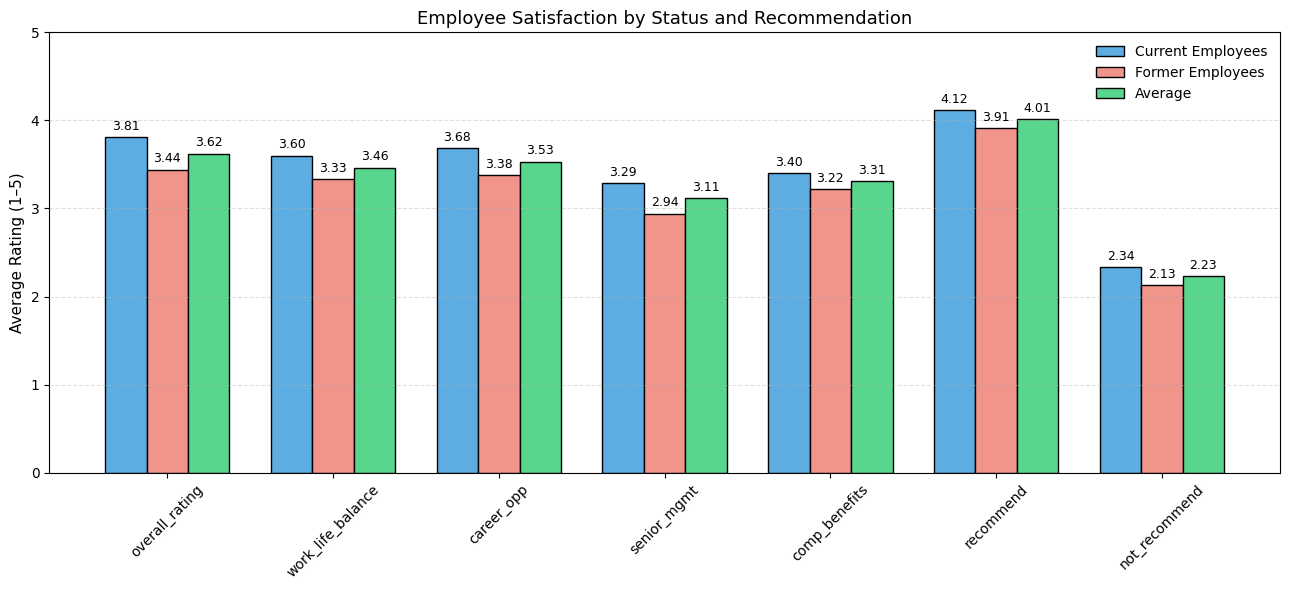

Labels: ['overall_rating', 'work_life_balance', 'career_opp', 'senior_mgmt', 'comp_benefits', 'recommend', 'not_recommend']
Current Employees: [3.80817561 3.59691906 3.68191627 3.28585391 3.40179468 4.11530348
 2.33560587]
Former Employees: [3.43972763 3.3316409  3.378318   2.94190114 3.2204108  3.91068108
 2.12802919]
Overall Average: [3.62395162 3.46427998 3.53011713 3.11387753 3.31110274 4.01299228
 2.23181753]


In [9]:
rating_cols = [
    'overall_rating',
    'work_life_balance',
    'career_opp',
    'senior_mgmt',
    'comp_benefits'
]

# =======================
# 1. Workplace factor means
# =======================
status_grouped = glassdoor_final.groupby('employee_status')[rating_cols].mean()

current_means = status_grouped.loc['current'].values
former_means = status_grouped.loc['former'].values

# =======================
# 2. Recommendation means (correct filtering)
# =======================
rec_grouped = (
    glassdoor_final
    .groupby(['employee_status', 'recommend_binary'])['overall_rating']
    .mean()
)

current_rec = rec_grouped.loc[('current', 1)]
current_not = rec_grouped.loc[('current', 0)]
former_rec = rec_grouped.loc[('former', 1)]
former_not = rec_grouped.loc[('former', 0)]

# =======================
# 3. Combine factors + recommendation
# =======================
labels = rating_cols + ['recommend', 'not_recommend']

current_ext = np.append(current_means, [current_rec, current_not])
former_ext = np.append(former_means, [former_rec, former_not])
overall_ext = (current_ext + former_ext) / 2

# =======================
# 4. Plot (GROUPED BAR CHART)
# =======================
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13,6))

bars1 = ax.bar(
    x - width, current_ext, width,
    label='Current Employees',
    color='#5DADE2', edgecolor='black'
)

bars2 = ax.bar(
    x, former_ext, width,
    label='Former Employees',
    color='#F1948A', edgecolor='black'
)

bars3 = ax.bar(
    x + width, overall_ext, width,
    label='Average',
    color='#58D68D', edgecolor='black'
)

# =======================
# 5. Styling
# =======================
ax.set_ylabel('Average Rating (1–5)', fontsize=11)
ax.set_title('Employee Satisfaction by Status and Recommendation', fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend(frameon=False)

ax.set_ylim(0, 5)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# =======================
# 6. Data labels
# =======================
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.05,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.show()

# Print all values
print("Labels:", labels)
print("Current Employees:", current_ext)
print("Former Employees:", former_ext)
print("Overall Average:", overall_ext)


### **Employee Satisfaction and Recommendation Likelihood Summary & Evaluation**

* **Current vs Former Employees:**

  * Current employees rate the company higher than former employees across all workplace factors.
  * Suggests former employees left due to dissatisfaction, especially with management or work environment.

* **Workplace Factors:**

  * **Senior management** has the lowest average rating (Current: 3.29, Former: 2.94) → potential leadership or communication issues.
  * **Overall rating** is moderate (Current: 3.81, Former: 3.44).
  * **Work-life balance** and **career opportunities** are slightly better for current employees.

* **Recommendation:**

  * Employees willing to recommend the company give high ratings (Current: 4.12, Former: 3.91).
  * Employees not willing to recommend give low ratings (Current: 2.34, Former: 2.13).
  * Recommendation clearly correlates with overall satisfaction → strong indicator of employee sentiment.

* **Overall Evaluation:**

  * The company shows **moderate satisfaction overall**, with **clear polarization** between satisfied and dissatisfied employees.
  * Key area for improvement: **senior management** and support for former employees who left.
  * Recommendation metrics are valuable for identifying **loyal vs dissatisfied employees**.

---

### 3. Correlation Analysis of Workplace Factors

To better understand the relationships between overall employee satisfaction and different workplace factors, a correlation analysis was conducted using key rating variables from the Glassdoor dataset.

This analysis focuses on the following factors:
- Overall company rating
- Work-life balance
- Career opportunities
- Senior management
- Compensation and benefits
- Recommendation likelihood

A correlation heatmap is used to visualize the strength and direction of relationships between these variables. This helps identify which factors are most closely associated with overall employee satisfaction and provides insights into areas that organizations should prioritize to improve employee experience.

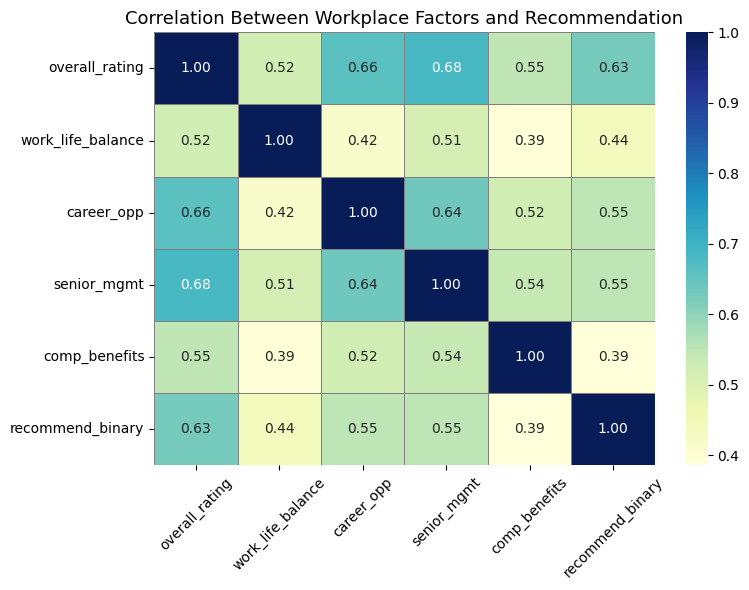

                   overall_rating  work_life_balance  career_opp  senior_mgmt  \
overall_rating           1.000000           0.521680    0.660960     0.684277   
work_life_balance        0.521680           1.000000    0.415344     0.512961   
career_opp               0.660960           0.415344    1.000000     0.636450   
senior_mgmt              0.684277           0.512961    0.636450     1.000000   
comp_benefits            0.546709           0.391664    0.520092     0.539798   
recommend_binary         0.627569           0.440352    0.549995     0.549740   

                   comp_benefits  recommend_binary  
overall_rating          0.546709          0.627569  
work_life_balance       0.391664          0.440352  
career_opp              0.520092          0.549995  
senior_mgmt             0.539798          0.549740  
comp_benefits           1.000000          0.385450  
recommend_binary        0.385450          1.000000  


In [10]:
# =======================
# Columns to include in heatmap
# =======================
heatmap_cols = [
    'overall_rating',
    'work_life_balance',
    'career_opp',
    'senior_mgmt',
    'comp_benefits',
    'recommend_binary'  # 1 = recommend, 0 = not recommend
]

# Compute correlation matrix
corr_matrix = glassdoor_final[heatmap_cols].corr()

# =======================
# Plot heatmap
# =======================
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    cbar=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Correlation Between Workplace Factors and Recommendation", fontsize=13)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print(corr_matrix)

### **Interpretation**

* The heatmap shows that all workplace factors are **positively correlated**, indicating that employees who rate one aspect 
  highly tend to rate others highly as well.

* **Senior management, career opportunities, and overall rating** are the strongest correlated factors, suggesting that leadership 
  quality and growth opportunities are the main drivers of overall satisfaction.

* **Work-life balance** and **compensation & benefits** show moderate correlations with other factors, meaning they influence satisfaction 
  but are less central than management and career growth.

* **Recommendation likelihood** (recommend_binary) is positively correlated with all factors, especially overall rating, 
  career opportunities, and senior management, confirming that satisfied employees are more likely to recommend the company.

* Overall, the analysis highlights that focusing on **strong leadership, clear career paths, and overall employee experience** 
  could improve satisfaction across all workplace factors and increase recommendation rates.

# Summary of How Research Question is Answered

**Research Question:**  
How do education, employment characteristics, and workplace factors influence income, employment outcomes, and employee satisfaction?

---

## 1. Education and Employment Outcomes (Dataset 1)

- **Salary Differences by School:**  
  - Graduates from **Professional / Law / Medicine** and **Computing / IT** schools generally have the highest median starting salaries.  
  - Moderate salaries are observed in **Business**, **Engineering**, **Science**, and **Other** schools.  
  - **Arts & Social Sciences** graduates have the lowest median starting salaries.

- **Employment Rates by Degree Field:**  
  - **Highest employability:** Medicine & Health, Law – almost all graduates secure employment, often in full-time permanent roles.  
  - **Moderate employability:** Business & Economics, Engineering – high overall employment, slightly lower full-time permanent rates.  
  - **Lowest employability:** Arts & Social Sciences, Other – lower overall and full-time permanent employment rates.  
  - Fields with high employability also show minimal gaps between overall and full-time permanent employment, indicating stable career outcomes.

**Conclusion:**  
Educational background strongly affects both starting salary and employment stability. Specialized or professional fields provide higher salaries and more secure employment.

---

## 2. Income Patterns and Demographics (Dataset 2 – MOM Employment Tables)

- **Income by Occupation and Gender:**  
  - High-skilled roles (e.g., Managers, Professionals) earn significantly more than lower-skilled roles (e.g., Cleaners, Labourers).  
  - Gender wage gap exists and is largest in high-paying occupations (~SGD 1,292 for managers), smaller in mid- or low-paying jobs, with occasional reverse gaps.  
  - Average gender income gap across occupations: ~SGD 477.

- **Income by Qualification and Age:**  
  - Higher qualifications lead to higher starting income, faster income growth, higher peak income, and longer sustained earnings.  
  - Degree holders show the most rapid growth and peak around age 50–54.  
  - The income gap between highest and lower qualifications widens with age; the largest gap (~SGD 7,416) occurs at 50–54 between Degree and Secondary holders.  
  - Lower qualifications experience slower growth and earlier decline in earnings.

**Conclusion:**  
Both occupation and educational attainment strongly influence income. Gender differences are pronounced in high-skilled roles, while higher qualifications consistently translate into greater lifetime earnings.

---

## 3. Employee Satisfaction and Workplace Perception (Dataset 3 – Glassdoor Reviews)

- **Impact of Workplace Factors:**  
  - Work-life balance, career opportunities, leadership quality, and compensation significantly affect overall employee satisfaction.  
  - Employees with better experiences in these areas report higher satisfaction and recommendation likelihood.

- **Differences Between Current and Former Employees:**  
  - Former employees tend to report lower satisfaction compared to current employees.  
  - Current employees are more likely to recommend their company, reflecting more positive workplace experiences.

**Conclusion:**  
Workplace environment and organizational factors strongly shape employee satisfaction. Companies that offer good work-life balance, career growth, strong management, and competitive compensation tend to have more satisfied and loyal employees.

---

## Overall Insights

1. **Education and Degree Choice:** Major determinant of starting salary and employability; specialized professional degrees offer higher earnings and stability.  
2. **Occupation and Experience:** High-skill occupations earn more; income growth depends on both occupation and qualification level.  
3. **Gender Gap:** Exists mainly in high-paying occupations; smaller or negligible in mid- and low-paying roles.  
4. **Workplace Factors:** Significantly influence employee satisfaction and recommendation behavior, complementing education and income outcomes.  
5. **Combined Effect:** Income, employment outcomes, and satisfaction are influenced by the interplay of education, occupation, and workplace environment.